In [1]:
import sympy
import numpy as np
from dms.robots import RR
from matplotlib import pyplot as plt
from dms.curves import cubic_interp
from matplotlib import animation
from IPython.display import HTML
from pathfinding.core.diagonal_movement import DiagonalMovement
from pathfinding.core.grid import Grid
from pathfinding.finder.a_star import AStarFinder

params={'L1':1,'L2':1.2}
robot=RR(params)

# Mover el robot
Sin perdida de generalizacion, podemos definir una tarea como mover el robot de un punto A a un punto.
Visualizamos donde comienza (A) y donde termina (B).

[  6.67599777 102.45219725]


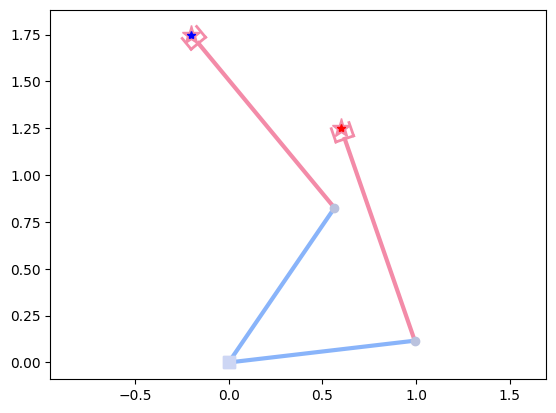

In [3]:
# Solucion cinematica inversa en caso A y B
pos_A=[-0.2,1.75]
pos_B=[0.6,1.25]
theta0=[0.2,0.2]
resultA=robot.inverse_kinematics(*pos_A, theta0)
resultB=robot.inverse_kinematics(*pos_B, theta0)
plt.axis('equal')
robot.plot(resultA)
robot.plot(resultB)
plt.plot(*pos_A,'*b')
plt.plot(*pos_B,'*r')
print(np.rad2deg(resultB))

# Interpolacion en Joint space

Text(0, 0.5, 'ángulo (deg)')

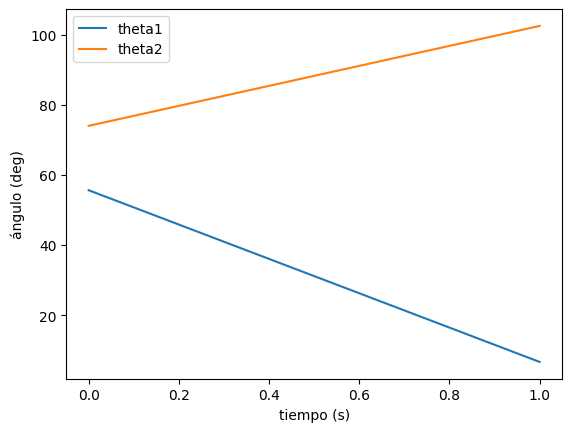

In [43]:
# Consideremos la interpolacion entre A y B
# Si fuera lineal que pasaria con el robot en el instante 0 y en el tiempo final?
plt.plot([0,1],np.rad2deg([resultA[0],resultB[0]]))
plt.plot([0,1],np.rad2deg([resultA[1],resultB[1]]))
plt.legend(['theta1','theta2'])
plt.xlabel('tiempo (s)')
plt.ylabel('ángulo (deg)')   
# Observe que la velocidad inicial y final no es cero. Si nuestro robot arranca
# y se detiene en A y B, entonces esta trayectoria no funciona. Por lo tanto
# requerimos una trayectoria que tenga velocidad inicial y final cero. Para esto, podemos usar una interpolacion cubica. 

# Interpolación en cartesian space

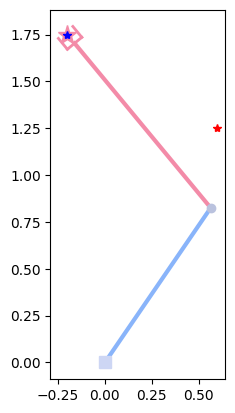

In [6]:
# Solucion cinematica en caso A y B
tt=np.linspace(0,1,10)
pos=cubic_interp(pos_A,np.zeros_like(pos_A),pos_B,np.zeros_like(pos_B))(tt)
fig=plt.figure()
theta0=[0.2,0.2]
thetaList=[]
def update(frame):    
    result=robot.inverse_kinematics(pos[frame,0],pos[frame,1],theta0)           
    thetaList.append(result)        
    plt.cla()
    robot.plot(result)
    plt.plot(*pos_A,'*b')
    plt.plot(*pos_B,'*r')
    
    
ani = animation.FuncAnimation(fig=fig, func=update, frames=len(tt))
HTML(ani.to_jshtml())


# Interpolación en joint space

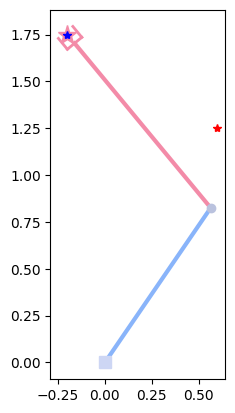

In [46]:
tt=np.linspace(0,1,10)
angles=cubic_interp(resultA,np.zeros_like(resultA),resultB,np.zeros_like(resultB))(tt)
fig=plt.figure()
thetaList=[]
def update(frame):        
    plt.cla()    
    robot.plot(angles[frame,:])
    plt.plot(*pos_A,'*b')
    plt.plot(*pos_B,'*r')
    
ani = animation.FuncAnimation(fig=fig, func=update, frames=len(tt))
HTML(ani.to_jshtml())


# Comparación

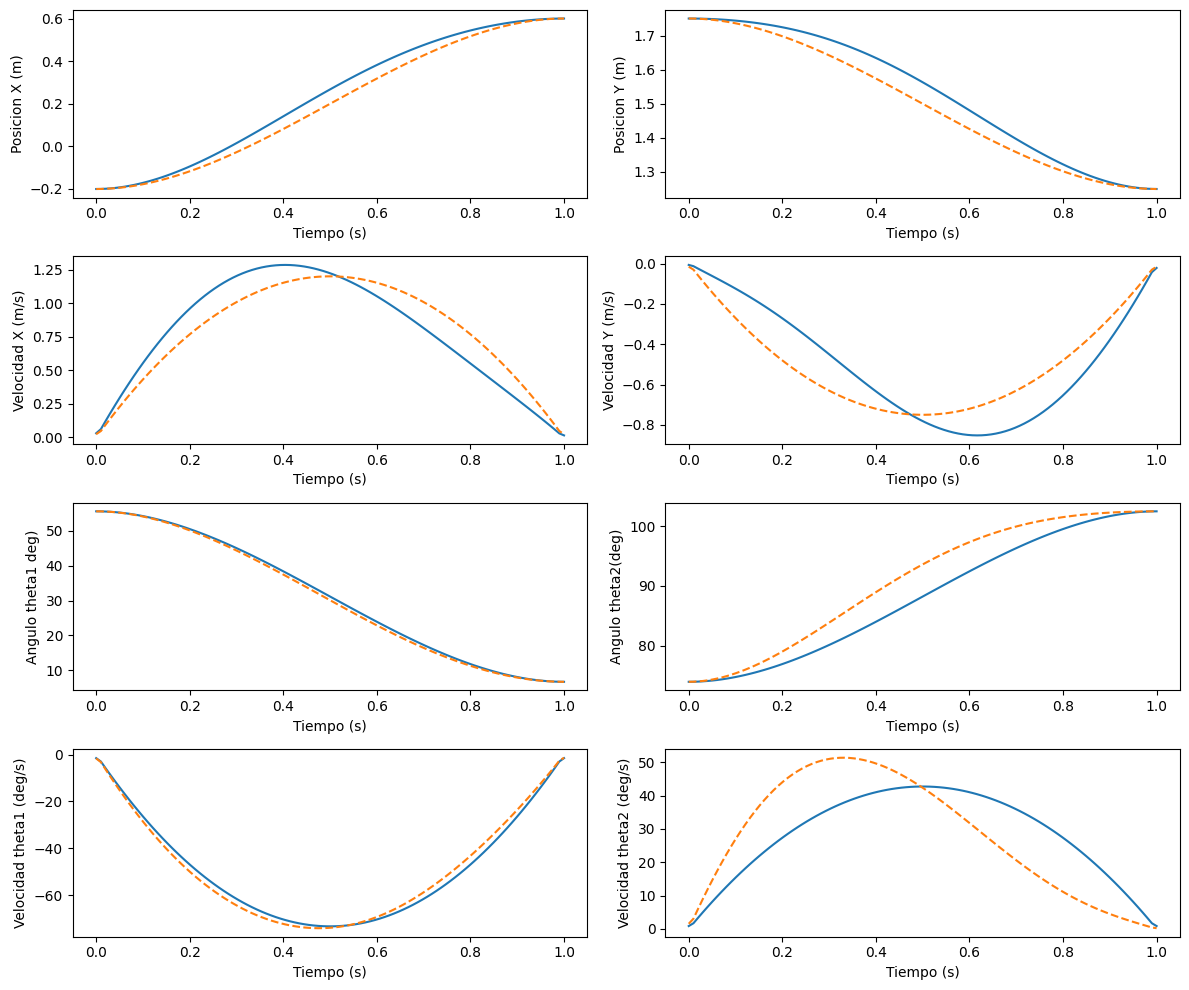

In [47]:
tt=np.linspace(0,1,100)
# Joint Space Interpolation
angles_joint=cubic_interp(resultA,np.zeros_like(resultA),resultB,np.zeros_like(resultB))(tt)
pos_joint=np.array([robot.forward_kinematics(angles)[robot.eef_name] for angles in angles_joint])
# Cartesian Space Interpolation
pos_cartesian=cubic_interp(pos_A,np.zeros_like(pos_A),pos_B,np.zeros_like(pos_B))(tt)
angles_cartesian=np.array([robot.inverse_kinematics(*pos,theta0) for pos in pos_cartesian])

plt.figure(figsize=(12,10))
plt.subplot(4,2,1)
plt.plot(tt,pos_joint[:,0])
plt.plot(tt,pos_cartesian[:,0],'--')
plt.xlabel('Tiempo (s)')
plt.ylabel('Posicion X (m)')

plt.subplot(4,2,2)
plt.plot(tt,pos_joint[:,1])
plt.plot(tt,pos_cartesian[:,1],'--')
plt.xlabel('Tiempo (s)')
plt.ylabel('Posicion Y (m)')

plt.subplot(4,2,3)
plt.plot(tt,np.gradient(pos_joint[:,0],tt,axis=0))
plt.plot(tt,np.gradient(pos_cartesian[:,0],tt,axis=0),'--')
plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad X (m/s)')

plt.subplot(4,2,4)
plt.plot(tt,np.gradient(pos_joint[:,1],tt,axis=0))
plt.plot(tt,np.gradient(pos_cartesian[:,1],tt,axis=0),'--')
plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad Y (m/s)')

plt.subplot(4,2,5)
plt.plot(tt,np.rad2deg(angles_joint[:,0]))
plt.plot(tt,np.rad2deg(angles_cartesian[:,0]),'--')
plt.xlabel('Tiempo (s)')
plt.ylabel('Angulo theta1 deg)')

plt.subplot(4,2,6)
plt.plot(tt,np.rad2deg(angles_joint[:,1]))
plt.plot(tt,np.rad2deg(angles_cartesian[:,1]),'--')
plt.xlabel('Tiempo (s)')
plt.ylabel('Angulo theta2(deg)')

plt.subplot(4,2,7)
plt.plot(tt,np.rad2deg(np.gradient(angles_joint[:,0],tt,axis=0)))
plt.plot(tt,np.rad2deg(np.gradient(angles_cartesian[:,0],tt,axis=0)),'--')
plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad theta1 (deg/s)')

plt.subplot(4,2,8)
plt.plot(tt,np.rad2deg(np.gradient(angles_joint[:,1],tt,axis=0)))
plt.plot(tt,np.rad2deg(np.gradient(angles_cartesian[:,1],tt,axis=0)),'--')
plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad theta2 (deg/s)')

plt.tight_layout()


# Exploremos el espacio de trabajo

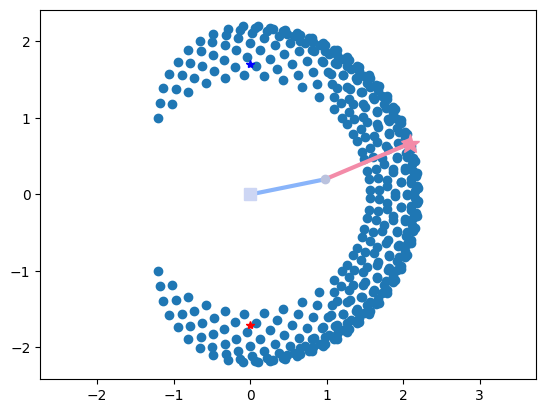

In [48]:
pos_A=[0,1.7]
pos_B=[0,-1.7]
thetas=np.deg2rad(np.linspace(-90,90,20))
th1_grid, th2_grid = np.meshgrid(thetas, thetas)
pos=robot._pts_fn[robot.eef_name](th1_grid,th2_grid)
plt.scatter(pos[0].flatten(),pos[1].flatten())
plt.plot(*pos_A,'b*')
plt.plot(*pos_B,'r*')
plt.axis('equal')
robot.plot(theta0)

# Observe que el robot no puede ir de A a B moviendose recto en el espacio cartesiano.

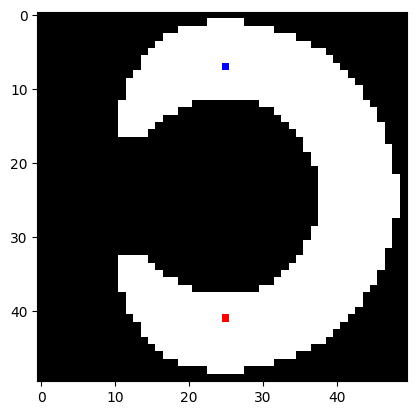

In [64]:
# Malla uniforme describiendo el espacio del robot
delta=np.linspace(-2.5,2.5,50)
x_grid, y_grid = np.meshgrid(delta,delta) 
# x[row idx][column idx]

# Comparar contra todos los puntos validos/invalidos del workspace para determinar
# si una posicion x,y es valida.
# Aqui se podria incorporar deteccion de colsiones o restricciones adicionales como 
# evitar regiones cercanas a singularidad.
def checkValidity(x,y,threshold=5e-2):
    distance2=(pos[0]-x)**2+(pos[1]-y)**2
    return np.min(distance2)<threshold

valid=np.zeros_like(x_grid)
for i in range(x_grid.shape[0]):
    for j in range(x_grid.shape[1]):
        valid[i,j]=checkValidity(x_grid[i,j],y_grid[i,j])
        
# Position to index in grid
idxA=np.flip(np.floor(len(delta)*(pos_A-np.min(delta))/(np.max(delta)-np.min(delta))).astype(int))
idxB=np.flip(np.floor(len(delta)*(pos_B-np.min(delta))/(np.max(delta)-np.min(delta))).astype(int))
visuals=np.stack([valid,valid,valid],axis=2)
visuals[*idxA,:]=[0,0,1]
visuals[*idxB,:]=[1,0,0]

plt.imshow(np.flipud(visuals))

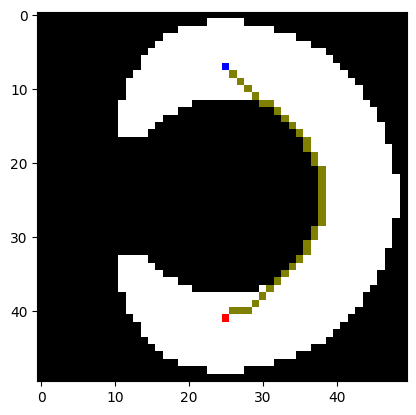

In [65]:
grid=Grid(matrix=valid.T) # Grid is filled by height_idx,width_idx
start=grid.node(*idxA)
end = grid.node(*idxB)
finder = AStarFinder(diagonal_movement=DiagonalMovement.always)
path, runs = finder.find_path(start, end, grid)
path_idx=[[node.x,node.y] for node in path]
visuals=np.stack([valid,valid,valid],axis=2)
for cell in path_idx:
    visuals[*cell,:]=[0.5,0.5,0]
visuals[*idxA,:]=[0,0,1]
visuals[*idxB,:]=[1,0,0]
plt.imshow(np.flipud(visuals))

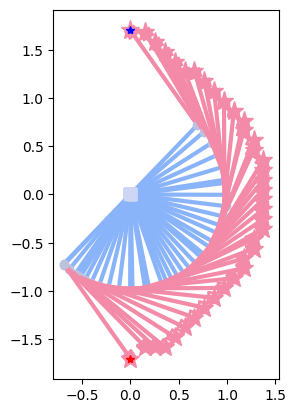

In [66]:
# Calculamos la trayectoria a partir de las celdas encontradas
traj_cartesian=[]
traj_thetas=[]
for i,cell in enumerate(path_idx):
    pos_desired=[x_grid[*cell],y_grid[*cell]]
    if i==0:
        pos_desired=pos_A
    if i==len(path_idx)-1:
        pos_desired=pos_B
    traj_cartesian.append(pos_desired)
    result=robot.inverse_kinematics(*pos_desired,theta0)
    traj_thetas.append(result)
    robot.plot(result)
    theta0=result
plt.plot(*pos_A,'b*')
plt.plot(*pos_B,'r*')
traj_cartesian=np.array(traj_cartesian)
traj_thetas=np.array(traj_thetas)

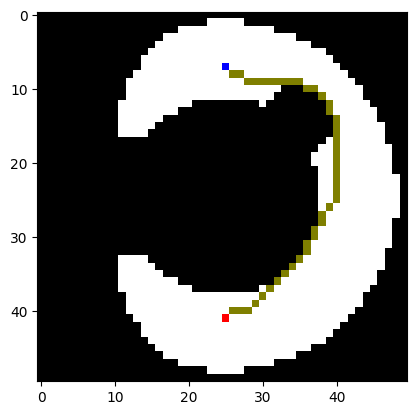

In [72]:
from dms.robots.workspace import CircleObstacle

obstacle=CircleObstacle(1.0,1,0.5)

# Malla uniforme describiendo el espacio del robot
delta=np.linspace(-2.5,2.5,50)
x_grid, y_grid = np.meshgrid(delta,delta) 
# x[row idx][column idx]

# Comparar contra todos los puntos validos/invalidos del workspace para determinar
# si una posicion x,y es valida.
# Aqui se podria incorporar deteccion de colsiones o restricciones adicionales como 
# evitar regiones cercanas a singularidad.
def checkValidity(x,y,threshold=5e-2):
    distance2=(pos[0]-x)**2+(pos[1]-y)**2    
    return np.min(distance2)<threshold and not obstacle.contains(x,y)  

valid=np.zeros_like(x_grid)
for i in range(x_grid.shape[0]):
    for j in range(x_grid.shape[1]):
        valid[i,j]=checkValidity(x_grid[i,j],y_grid[i,j])
        
# Position to index in grid
idxA=np.flip(np.floor(len(delta)*(pos_A-np.min(delta))/(np.max(delta)-np.min(delta))).astype(int))
idxB=np.flip(np.floor(len(delta)*(pos_B-np.min(delta))/(np.max(delta)-np.min(delta))).astype(int))
visuals=np.stack([valid,valid,valid],axis=2)
visuals[*idxA,:]=[0,0,1]
visuals[*idxB,:]=[1,0,0]

grid=Grid(matrix=valid.T) # Grid is filled by height_idx,width_idx
start=grid.node(*idxA)
end = grid.node(*idxB)
finder = AStarFinder(diagonal_movement=DiagonalMovement.always)
path, runs = finder.find_path(start, end, grid)
path_idx=[[node.x,node.y] for node in path]
visuals=np.stack([valid,valid,valid],axis=2)
for cell in path_idx:
    visuals[*cell,:]=[0.5,0.5,0]
visuals[*idxA,:]=[0,0,1]
visuals[*idxB,:]=[1,0,0]
plt.imshow(np.flipud(visuals))


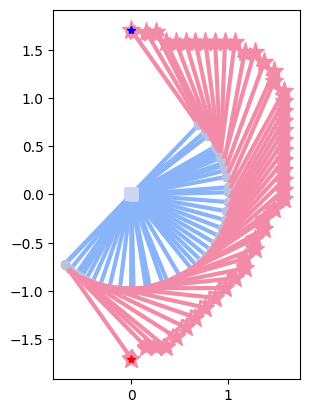

In [71]:
# Calculamos la trayectoria a partir de las celdas encontradas
traj_cartesian=[]
traj_thetas=[]
for i,cell in enumerate(path_idx):
    pos_desired=[x_grid[*cell],y_grid[*cell]]
    if i==0:
        pos_desired=pos_A
    if i==len(path_idx)-1:
        pos_desired=pos_B
    traj_cartesian.append(pos_desired)
    result=robot.inverse_kinematics(*pos_desired,theta0)
    traj_thetas.append(result)
    robot.plot(result)
    theta0=result
plt.plot(*pos_A,'b*')
plt.plot(*pos_B,'r*')
traj_cartesian=np.array(traj_cartesian)
traj_thetas=np.array(traj_thetas)